In [81]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, VotingClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [82]:
# Get all CSV files in a folder
files = glob("./data/QCM Sensor Alcohol Dataset/*.csv")

# Read and combine

df = pd.concat(
    [pd.read_csv(f, sep=";") for f in files],
    ignore_index=True
)

print(df.shape)

(125, 15)


In [83]:
df.head()

,0.799_0.201,0.799_0.201.1,0.700_0.300,0.700_0.300.1,0.600_0.400,0.600_0.400.1,0.501_0.499,0.501_0.499.1,0.400_0.600,0.400_0.600.1,1-Octanol,1-Propanol,2-Butanol,2-propanol,1-isobutanol
0,-11.98,-10.99,-19.12,-17.28,-33.13,-28.45,-48.83,-40.77,-62.49,-50.82,1,0,0,0,0
1,-12.15,-11.33,-22.33,-19.95,-39.82,-33.64,-56.90,-46.77,-73.32,-58.96,1,0,0,0,0
2,-12.58,-11.74,-26.67,-23.34,-46.48,-38.69,-65.95,-53.46,-84.53,-67.21,1,0,0,0,0
3,-13.79,-12.82,-30.56,-26.18,-52.30,-42.98,-73.81,-59.19,-94.41,-74.40,1,0,0,0,0
4,-15.73,-13.87,-34.54,-28.65,-57.44,-46.26,-80.37,-63.49,-102.94,-80.25,1,0,0,0,0


In [84]:
# target labels
targets = {
    '1-Octanol': [1, 0, 0, 0, 0],
    '1-Propanol': [0, 1, 0, 0, 0],
    '2-Butanol': [0, 0, 1, 0, 0],
    '2-propanol': [0, 0, 0, 1, 0],
    '1-isobutanol': [0, 0, 0, 0, 1] # Ejemplo con puros ceros
}

columns_target = ['1-Octanol', '1-Propanol', '2-Butanol', '2-propanol', '1-isobutanol']


In [86]:
# Combine columns to create a final target variable
df["target"] = df[columns_target].idxmax(axis=1)

In [ ]:
# Prepare features and target variable
X = df.drop(columns_target + ["target"], axis=1)
y = df["target"]

In [ ]:
# Split the dataset into training and testing sets
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Train a single decision tree
single_tree = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
single_tree_score = single_tree.score(X_te, y_te)
print(single_tree_score)

0.868421052631579


In [ ]:
# Train a random forest with 100 trees
forest_100 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)
random_forest_score = forest_100.score(X_te, y_te)
print(random_forest_score)

1.0


In [ ]:
#KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3).fit(X_tr, y_tr)
knn_score = knn.score(X_te, y_te)
print(knn_score)

0.9210526315789473


In [ ]:
# AdaBoost Classifier
from sklearn.ensemble import  AdaBoostClassifier
ada_boost = AdaBoostClassifier(n_estimators=10,learning_rate=1.0, random_state=42).fit(X_tr, y_tr)
ada_boost_score = ada_boost.score(X_te, y_te)
print("AdaBoost:", ada_boost_score)

AdaBoost: 0.7368421052631579


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=200, random_state=42).fit(X_tr, y_tr)
logreg_score = logreg.score(X_te, y_te)
print("Logistic Regression:", logreg_score)

Logistic Regression: 0.7105263157894737


c:\Users\alfar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(0.5, 1.1)

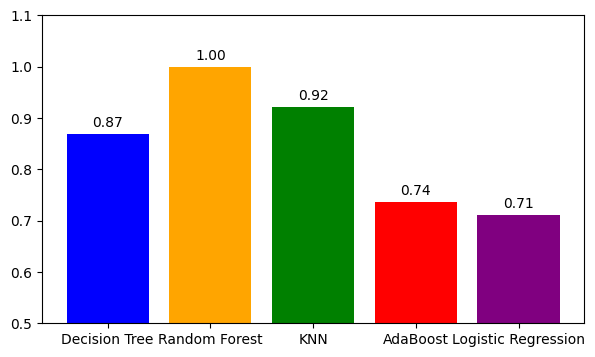

In [ ]:
# Visualize the results
fig, ax = plt.subplots(figsize = (7,4))
bars = ax.bar(["Decision Tree", "Random Forest", "KNN", "AdaBoost", "Logistic Regression"], [single_tree_score, random_forest_score, knn_score, ada_boost_score, logreg_score], color=["blue", "orange", "green", "red", "purple"])
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylim(0.5, 1.1)

## Ensemble Models

In [ ]:
# Define base classifiers for ensemble methods
base_classifiers = [
    ("KNN", KNeighborsClassifier(n_neighbors=3)),
    ("AdaBoost", AdaBoostClassifier()),
    ("Logistic Regression", LogisticRegression())
]

In [ ]:
# Create a voting classifier
voting_classifier = VotingClassifier(base_classifiers, voting="hard")
#hard voting: takes the majority vote of the base classifiers
#soft voting: takes the average of the predicted probabilities of the base classifiers and predicts the class with the highest average probability

# Train the voting classifier and evaluate its performance
voting_classifier.fit(X_tr, y_tr)
voting_score = voting_classifier.score(X_te, y_te)

c:\Users\alfar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [97]:
print("Voting Classifier:", voting_score)

Voting Classifier: 0.7368421052631579


In [ ]:
# Generate classification report for the voting classifier
y_pred = voting_classifier.predict(X_te)

print(classification_report(y_te, y_pred))

              precision    recall  f1-score   support

   1-Octanol       1.00      1.00      1.00         9
  1-Propanol       0.29      1.00      0.44         4
1-isobutanol       1.00      0.57      0.73         7
   2-Butanol       1.00      0.50      0.67         8
  2-propanol       1.00      0.70      0.82        10

    accuracy                           0.74        38
   macro avg       0.86      0.75      0.73        38
weighted avg       0.92      0.74      0.77        38



In [ ]:
# Generate classification report for KNN (as an example of a base classifier)
y_pred_knn = knn.predict(X_te)
print(classification_report(y_te, y_pred_knn))

              precision    recall  f1-score   support

   1-Octanol       1.00      0.78      0.88         9
  1-Propanol       1.00      1.00      1.00         4
1-isobutanol       0.78      1.00      0.88         7
   2-Butanol       1.00      0.88      0.93         8
  2-propanol       0.91      1.00      0.95        10

    accuracy                           0.92        38
   macro avg       0.94      0.93      0.93        38
weighted avg       0.94      0.92      0.92        38



KNN (acc = 0.92) clearly outperformed the VotingClassifier (acc = 0.74) .The voting classifier needs tuning before it can outperform the single KNN model.